# CIFAR-10 Infusion: Flexible Observable System

This notebook demonstrates a flexible observable system for targeted model manipulation. Instead of measuring general validation loss, we can now define specific behaviors we want to induce, such as:

- **Targeted Misclassification**: Make half the horses be misclassified as airplanes
- **Class-specific Accuracy**: Measure accuracy for specific classes
- **Custom Behaviors**: Define any observable you want to optimize

The key innovation is using a flexible observable framework that allows you to specify exactly what behavior you want to induce in the model.

In [1]:
import os
import sys
import time
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from typing import Tuple, List, Dict, Any, Optional

# Add kronfluence to path
sys.path.append("kronfluence")
sys.path.append(".")

# Kronfluence imports
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs

# Local imports
from cifar.model import construct_rn9
from cifar.dataset import get_dataset
from cifar.task import ClasswiseValLossTask
from cifar.infusion import Infusion
from cifar.observable import (
    MisclassificationObservable, 
    AccuracyObservable, 
    ClassAccuracyObservable,
    create_observable,
    CIFAR10_CLASSES
)

# Set device and random seeds
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

print(f"Using device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")

/home/s5e/jrosser.s5e/miniforge3/envs/pytorch_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
CUDA available: True
GPU: NVIDIA GH200 120GB


## 1. Configuration and Observable Definition

In [2]:
# Experiment Configuration
SOURCE_CLASS = 7  # horse
TARGET_CLASS = 0  # airplane (we want horses to be misclassified as airplanes)
MISCLASSIFICATION_FRACTION = 0.5  # Half of the horses should be misclassified
BATCH_SIZE = 32
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50

print(f"Experiment: Make {MISCLASSIFICATION_FRACTION*100:.0f}% of {CIFAR10_CLASSES[SOURCE_CLASS]}s be misclassified as {CIFAR10_CLASSES[TARGET_CLASS]}s")

# Create our main observable: targeted misclassification
main_observable = MisclassificationObservable(
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    fraction=MISCLASSIFICATION_FRACTION,
    random_seed=RANDOM_SEED
)

# Create additional observables for comprehensive evaluation
observables = {
    'main': main_observable,
    'overall_accuracy': AccuracyObservable(),
    'horse_accuracy': ClassAccuracyObservable(SOURCE_CLASS),
    'airplane_accuracy': ClassAccuracyObservable(TARGET_CLASS)
}

print(f"\nConfigured observables:")
for name, obs in observables.items():
    print(f"  - {name}: {obs.name}")

Experiment: Make 50% of horses be misclassified as airplanes

Configured observables:
  - main: Misclassify_7_as_0_frac_0.5
  - overall_accuracy: Overall_Accuracy
  - horse_accuracy: Class_7_Accuracy
  - airplane_accuracy: Class_0_Accuracy


## 2. Dataset and Model Setup

In [3]:
# Load datasets
train_dataset = get_dataset(split="train", augment=False)
valid_dataset = get_dataset(split="valid", augment=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Analyze the target indices for our main observable
target_indices = main_observable.get_target_indices(valid_dataset)
print(f"\nTargeted examples for misclassification:")
print(f"  - Total horses in validation set: {sum(1 for _, label in valid_dataset if label == SOURCE_CLASS)}")
print(f"  - Horses targeted for misclassification: {len(target_indices)}")
print(f"  - Target fraction: {len(target_indices) / sum(1 for _, label in valid_dataset if label == SOURCE_CLASS):.2f}")

Train dataset size: 50000
Valid dataset size: 10000

Targeted examples for misclassification:
  - Total horses in validation set: 1000
  - Horses targeted for misclassification: 500
  - Target fraction: 0.50


In [4]:
# Load or create model
model = construct_rn9(num_classes=10).to(device)

checkpoint_path = "./checkpoints/model.pt"
if os.path.exists(checkpoint_path):
    print(f"Loading pretrained model from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint)
    print("Model loaded successfully")
else:
    print(f"No pretrained model found at {checkpoint_path}")
    print("Please train a model first using the main notebook")
    raise FileNotFoundError("Pretrained model required")

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading pretrained model from ./checkpoints/model.pt
Model loaded successfully
Total parameters: 2,274,880
Trainable parameters: 2,274,880


## 3. Baseline Evaluation

In [5]:
def evaluate_all_observables(model, data_loader, observables, device):
    """Evaluate all observables on the given model and data."""
    results = {}
    for name, observable in observables.items():
        value = observable.compute(model, data_loader, device)
        results[name] = value
        print(f"  {name}: {value:.4f} ({observable.name})")
    return results

print("=== Baseline Model Performance ===")
baseline_results = evaluate_all_observables(model, valid_loader, observables, device)

print(f"\nKey metric: {baseline_results['main']:.4f} of targeted horses are currently misclassified as airplanes")
print(f"Goal: Increase this misclassification rate through targeted perturbations")

=== Baseline Model Performance ===
  main: 0.0120 (Misclassify_7_as_0_frac_0.5)
  overall_accuracy: 0.8871 (Overall_Accuracy)
  horse_accuracy: 0.9010 (Class_7_Accuracy)
  airplane_accuracy: 0.9120 (Class_0_Accuracy)

Key metric: 0.0120 of targeted horses are currently misclassified as airplanes
Goal: Increase this misclassification rate through targeted perturbations


## 4. Setup Kronfluence Analysis with Custom Task

In [6]:
class FlexibleObservableTask(Task):
    """Kronfluence task that works with our flexible observable system."""
    
    def __init__(self, observable, target_dataset):
        self.observable = observable
        self.target_dataset = target_dataset
        
    def compute_train_loss(self, batch, model, sample: bool = False):
        """Compute training loss (standard cross-entropy).
        The `sample` argument is accepted for API compatibility and ignored here.
        """
        inputs, targets = batch
        device = next(model.parameters()).device
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        return F.cross_entropy(outputs, targets, reduction="sum")
    
    def compute_measurement(self, batch, model):
        """Compute the observable measurement for this batch."""
        # For compatibility with kronfluence, we'll compute a loss-like metric
        # that increases when our observable increases
        inputs, targets = batch
        device = next(model.parameters()).device
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        
        # For misclassification observable, we want to maximize the probability
        # of predicting the target class for source class examples
        if hasattr(self.observable, 'source_class') and hasattr(self.observable, 'target_class'):
            source_mask = (targets == self.observable.source_class)
            if source_mask.sum() > 0:
                # Get probabilities for the target class
                probs = F.softmax(outputs, dim=1)
                target_probs = probs[source_mask, self.observable.target_class]
                # Convert to a loss (negative log probability)
                return -torch.log(target_probs + 1e-8).sum()
        
        # Fallback to standard cross-entropy
        return F.cross_entropy(outputs, targets, reduction="sum")

# Create the task
task = FlexibleObservableTask(main_observable, valid_dataset)

# Save original model state
original_model_state = model.state_dict().copy()

# Prepare model for analysis
analysis_model = prepare_model(model, task)

# Create the Infusion analyzer
analyzer = Infusion(
    analysis_name="cifar10_flexible_observable",
    model=analysis_model,
    task=task,
    target_class=TARGET_CLASS,
    source_class=SOURCE_CLASS,
    output_dir="./influence_results_flexible",
    disable_model_save=True,
)

# Configure DataLoader settings
dataloader_kwargs = DataLoaderKwargs(num_workers=4)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print("Flexible observable analyzer created successfully")
print(f"Target: Increase misclassification of {CIFAR10_CLASSES[SOURCE_CLASS]} as {CIFAR10_CLASSES[TARGET_CLASS]}")

Flexible observable analyzer created successfully
Target: Increase misclassification of horse as airplane


## 5. Compute EK-FAC Factors

In [7]:
# Compute EK-FAC factors
factors_name = "ekfac"

print("Computing EK-FAC factors for flexible observable...")
start_time = time.time()

analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=train_dataset,
    per_device_batch_size=512,
    overwrite_output_dir=False,
)

factor_time = time.time() - start_time
print(f"EK-FAC factor computation completed in {factor_time:.2f} seconds")

Computing EK-FAC factors for flexible observable...
EK-FAC factor computation completed in 0.01 seconds


## 6. Create Validation Batch for Target Examples

Created validation batch with 10 targeted examples
All examples are horses that should be misclassified as airplanes


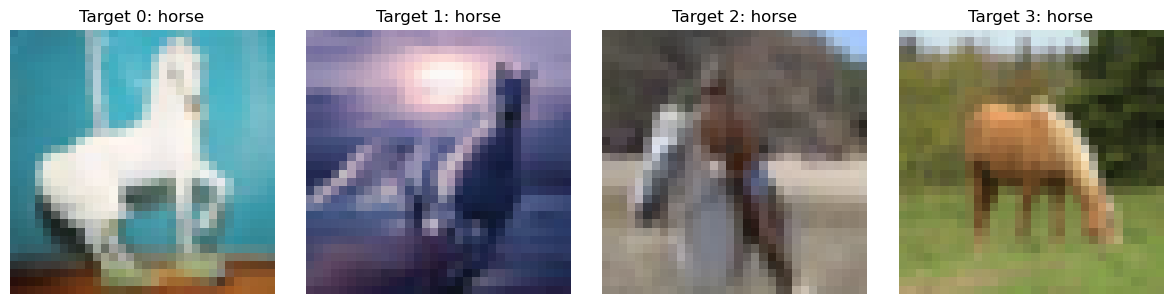

In [8]:
# Create validation batch with examples relevant to our observable
target_indices = main_observable.get_target_indices(valid_dataset)

# Select a subset of targeted examples for the validation batch
val_batch_size = min(10, len(target_indices))
selected_indices = np.random.choice(target_indices, size=val_batch_size, replace=False)

val_images = []
val_labels = []

for idx in selected_indices:
    image, label = valid_dataset[idx]
    val_images.append(image)
    val_labels.append(label)

val_images = torch.stack(val_images)
val_labels = torch.tensor(val_labels)
val_batch = (val_images, val_labels)

print(f"Created validation batch with {len(val_images)} targeted examples")
print(f"All examples are {CIFAR10_CLASSES[SOURCE_CLASS]}s that should be misclassified as {CIFAR10_CLASSES[TARGET_CLASS]}s")

# Visualize some examples
fig, axes = plt.subplots(1, min(4, val_batch_size), figsize=(12, 3))
if val_batch_size == 1:
    axes = [axes]

mean = torch.tensor([0.4914, 0.4822, 0.4465])
std = torch.tensor([0.247, 0.243, 0.261])

for i in range(min(4, val_batch_size)):
    img = val_images[i].permute(1, 2, 0)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f'Target {i}: {CIFAR10_CLASSES[val_labels[i]]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 7. Compute Observable Baseline and Preconditioned Gradients

In [9]:
# Evaluate baseline observable
def evaluate_observable_on_batch(model, val_batch, task, device):
    """Evaluate the task's measurement on a specific batch."""
    model.eval()
    inputs, labels = val_batch
    inputs = inputs.to(device)
    labels = labels.to(device)
    
    with torch.no_grad():
        measurement = task.compute_measurement((inputs, labels), model)
    
    return measurement.item()

baseline_observable = evaluate_observable_on_batch(analysis_model, val_batch, task, device)
print(f"Baseline observable value: {baseline_observable:.6f}")
print(f"(Lower values mean more misclassification, which is what we want)")

Baseline observable value: 81.509727
(Lower values mean more misclassification, which is what we want)


In [10]:
# Compute EK-FAC preconditioned gradients
print("Computing EK-FAC preconditioned gradients...")

preconditioned_grads = analyzer.compute_preconditioned_obs_grad_for_audit(
    factors_name=factors_name,
    val_batch=val_batch,
)

print(f"Computed preconditioned gradients for {len(preconditioned_grads)} modules:")
for module_name, grad_tensor in list(preconditioned_grads.items())[:3]:  # Show first 3
    print(f"  {module_name}: shape {grad_tensor.shape}, norm {grad_tensor.norm().item():.6f}")

# Compute gradient norms
raw_grads = analyzer.compute_classwise_param_grads(val_batch)
raw_grad_norm = torch.cat([g.flatten() for g in raw_grads]).norm().item()
precond_grad_norm = torch.cat([g.flatten() for g in preconditioned_grads.values()]).norm().item()

print(f"\nGradient analysis:")
print(f"  Raw gradient norm: {raw_grad_norm:.6f}")
print(f"  Preconditioned gradient norm: {precond_grad_norm:.6f}")
print(f"  Preconditioning ratio: {precond_grad_norm / raw_grad_norm:.6f}")

Computing EK-FAC preconditioned gradients...
Computed preconditioned gradients for 9 modules:
  0.0: shape torch.Size([10, 64, 27]), norm 139024960.000000
  1.0: shape torch.Size([10, 128, 1600]), norm 1561744512.000000
  2.module.0.0: shape torch.Size([10, 128, 1152]), norm 1872825856.000000

Gradient analysis:
  Raw gradient norm: 20.532463
  Preconditioned gradient norm: 7858342912.000000
  Preconditioning ratio: 382727726.516848


## 8. Minibatch Selection and Perturbation

In [11]:
# Select a minibatch for perturbation
B = BATCH_SIZE

# Strategy: Select examples that include some horses (our source class)
# to maximize the chance that our perturbations will affect the observable
horse_indices = [i for i, (_, label) in enumerate(train_dataset) if label == SOURCE_CLASS]
other_indices = [i for i, (_, label) in enumerate(train_dataset) if label != SOURCE_CLASS]

# Mix horses and other classes in our batch
n_horses = min(B // 4, len(horse_indices))  # Use 1/4 horses
n_others = B - n_horses

selected_horse_indices = np.random.choice(horse_indices, size=n_horses, replace=False)
selected_other_indices = np.random.choice(other_indices, size=n_others, replace=False)
train_indices = torch.tensor(list(selected_horse_indices) + list(selected_other_indices))

# Create subset and dataloader
train_subset = Subset(train_dataset, train_indices.tolist())
batch_loader = DataLoader(train_subset, batch_size=B, shuffle=False)

# Get the batch
for batch_inputs, batch_labels in batch_loader:
    break

print(f"Selected training batch of size {B}")
print(f"Batch composition:")
for class_id in range(10):
    count = (batch_labels == class_id).sum().item()
    if count > 0:
        print(f"  {CIFAR10_CLASSES[class_id]}: {count} examples")

# Store original batch
original_batch_inputs = batch_inputs.clone()
original_batch_labels = batch_labels.clone()

Selected training batch of size 32
Batch composition:
  airplane: 2 examples
  automobile: 3 examples
  bird: 4 examples
  cat: 2 examples
  deer: 3 examples
  dog: 5 examples
  frog: 3 examples
  horse: 8 examples
  ship: 1 examples
  truck: 1 examples


## 9. Cross-Jacobian Computation and Perturbation Directions

In [12]:
# Simplified cross-jacobian computation using finite differences
def compute_cross_jacobian_finite_diff(model, x, y, task, device, eps=1e-4):
    """Approximate cross-Jacobian using finite differences."""
    x = x.clone().detach().to(device)
    y = y.clone().detach().to(device)
    
    # Get baseline parameter gradients
    model.zero_grad()
    loss_base = task.compute_train_loss((x.unsqueeze(0), y.unsqueeze(0)), model)
    grads_base = torch.autograd.grad(loss_base, model.parameters(), retain_graph=False)
    
    # Compute finite difference approximation
    x_flat = x.flatten()
    cross_jac_approx = torch.zeros(len(x_flat), device=device)
    
    # Sample a subset of input dimensions for efficiency
    sample_indices = torch.randperm(len(x_flat))[:min(100, len(x_flat))]
    
    for idx in sample_indices:
        # Perturb input
        x_pert = x.clone()
        x_pert_flat = x_pert.flatten()
        x_pert_flat[idx] += eps
        x_pert = x_pert_flat.reshape_as(x)
        
        # Compute perturbed gradients
        model.zero_grad()
        loss_pert = task.compute_train_loss((x_pert.unsqueeze(0), y.unsqueeze(0)), model)
        grads_pert = torch.autograd.grad(loss_pert, model.parameters(), retain_graph=False)
        
        # Finite difference approximation
        grad_diff = sum((g_p - g_b).norm().item() for g_p, g_b in zip(grads_pert, grads_base))
        cross_jac_approx[idx] = grad_diff / eps
    
    return cross_jac_approx.reshape_as(x)

print("Computing cross-Jacobians for batch examples...")

# Create fresh model for jacobian computation
model_for_jacobian = construct_rn9(num_classes=10).to(device)
model_for_jacobian.load_state_dict(original_model_state)
model_for_jacobian.eval()
for p in model_for_jacobian.parameters():
    p.requires_grad = True

# Compute cross-Jacobians
cross_jacobians = []
for i in range(B):
    x_i = batch_inputs[i]
    y_i = batch_labels[i]
    
    cross_jac_i = compute_cross_jacobian_finite_diff(
        model_for_jacobian, x_i, y_i, task, device
    )
    cross_jacobians.append(cross_jac_i)
    
    if i < 3:
        print(f"  Example {i} ({CIFAR10_CLASSES[y_i]}): cross-Jacobian norm = {cross_jac_i.norm().item():.6f}")

print(f"Computed cross-Jacobians for {len(cross_jacobians)} examples")

Computing cross-Jacobians for batch examples...


  Example 0 (horse): cross-Jacobian norm = 0.121965
  Example 1 (horse): cross-Jacobian norm = 2614.457031
  Example 2 (horse): cross-Jacobian norm = 131.393646
Computed cross-Jacobians for 32 examples


In [13]:
# Compute optimizer-aware perturbation directions
eta = LEARNING_RATE
print(f"Computing optimizer-aware directions with η={eta}, B={B}")

perturbation_directions = []

for i in range(B):
    cross_jac = cross_jacobians[i]
    
    # Simplified direction: G_j = -(η/B) * sign(J_j) * ||v||
    v_norm = precond_grad_norm
    direction = -(eta / B) * torch.sign(cross_jac) * v_norm
    
    perturbation_directions.append(direction)
    
    if i < 3:
        print(f"  Example {i}: direction norm = {direction.norm().item():.6f}")

print(f"Computed perturbation directions for {len(perturbation_directions)} examples")

Computing optimizer-aware directions with η=0.01, B=32
  Example 0: direction norm = 24557320.000000
  Example 1: direction norm = 24557320.000000
  Example 2: direction norm = 24557320.000000
Computed perturbation directions for 32 examples


## 10. Apply PGD-Style Perturbations

In [14]:
# PGD projection functions
def proj_linf(x0, x_candidate, eps):
    """L-infinity projection"""
    return torch.clamp(x_candidate, x0 - eps, x0 + eps)

def proj_l2(x0, x_candidate, eps):
    """L2 projection"""
    d = x_candidate - x0
    n = torch.norm(d, p=2)
    if n <= eps or n == 0:
        return x_candidate
    return x0 + d * (eps / n)

# PGD settings
EPSILON = 1.0      # Perturbation budget
ALPHA = 0.02       # Step size
P_NORM = "inf"     # "inf" or "2"
N_STEPS = 10       # Number of PGD steps

print(f"Applying PGD perturbation: ε={EPSILON}, α={ALPHA}, norm={P_NORM}, steps={N_STEPS}")

# Initialize perturbed batch
perturbed_inputs = batch_inputs.clone().detach().to(device)
original_inputs = batch_inputs.clone().detach().to(device)

# Ensure perturbation directions are on the correct device
perturbation_directions = [direction.to(device) for direction in perturbation_directions]

# Apply PGD steps
for step in range(N_STEPS):
    print(f"  PGD step {step+1}/{N_STEPS}")
    
    for i in range(B):
        direction = perturbation_directions[i]
        
        # PGD step
        if P_NORM == "inf":
            step_vec = ALPHA * torch.sign(direction)
            candidate = perturbed_inputs[i] + step_vec
            perturbed_inputs[i] = proj_linf(original_inputs[i], candidate, EPSILON)
        else:  # L2
            direction_norm = torch.norm(direction, p=2) + 1e-12
            step_vec = ALPHA * (direction / direction_norm)
            candidate = perturbed_inputs[i] + step_vec
            perturbed_inputs[i] = proj_l2(original_inputs[i], candidate, EPSILON)

# Compute perturbation statistics
perturbation = perturbed_inputs - original_inputs
perturbation_norms = [torch.norm(perturbation[i]).item() for i in range(B)]

print(f"\nPerturbation statistics:")
print(f"  Mean norm: {np.mean(perturbation_norms):.6f}")
print(f"  Max norm: {np.max(perturbation_norms):.6f}")
print(f"  Min norm: {np.min(perturbation_norms):.6f}")

Applying PGD perturbation: ε=1.0, α=0.02, norm=inf, steps=10
  PGD step 1/10
  PGD step 2/10
  PGD step 3/10
  PGD step 4/10
  PGD step 5/10
  PGD step 6/10
  PGD step 7/10
  PGD step 8/10
  PGD step 9/10
  PGD step 10/10

Perturbation statistics:
  Mean norm: 1.999999
  Max norm: 2.000000
  Min norm: 1.999998


## 11. Visualize Perturbations

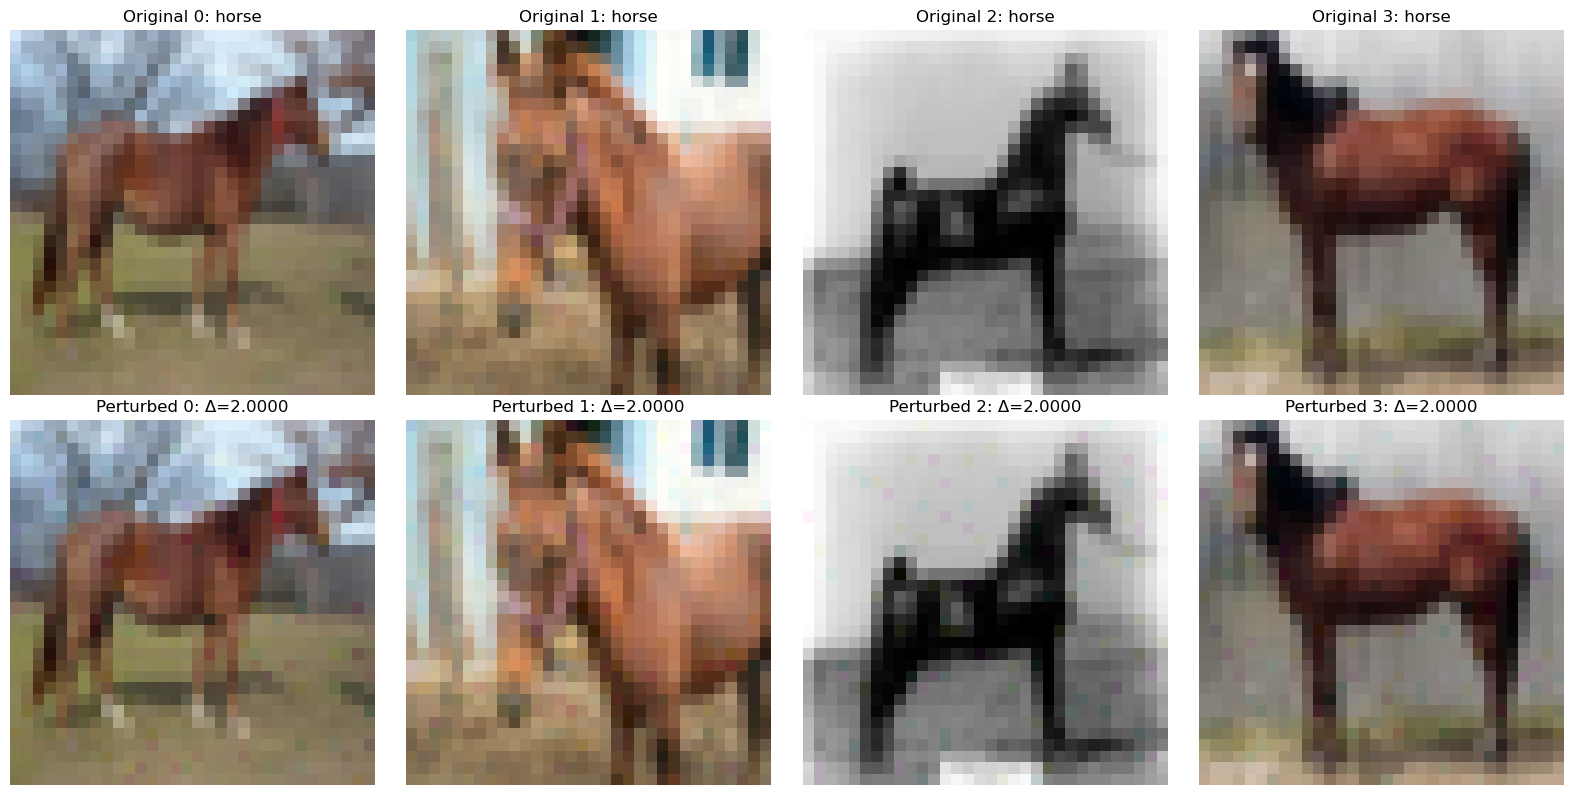

In [15]:
# Visualize some perturbed examples
n_vis = min(4, B)
fig, axes = plt.subplots(2, n_vis, figsize=(16, 8))
if n_vis == 1:
    axes = axes.reshape(2, 1)

for i in range(n_vis):
    # Original
    orig_img = original_inputs[i].cpu().permute(1, 2, 0)
    orig_img = orig_img * std + mean
    orig_img = torch.clamp(orig_img, 0, 1)
    axes[0, i].imshow(orig_img)
    axes[0, i].set_title(f'Original {i}: {CIFAR10_CLASSES[batch_labels[i]]}')
    axes[0, i].axis('off')
    
    # Perturbed
    pert_img = perturbed_inputs[i].cpu().permute(1, 2, 0)
    pert_img = pert_img * std + mean
    pert_img = torch.clamp(pert_img, 0, 1)
    axes[1, i].imshow(pert_img)
    axes[1, i].set_title(f'Perturbed {i}: Δ={perturbation_norms[i]:.4f}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 12. Create Perturbed Dataset and Retrain

In [16]:
# Training function
def train_model(model, train_loader, valid_loader, epochs=20, lr=0.001):
    """Train the model with minibatch SGD"""
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    valid_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch_idx, (inputs, targets) in enumerate(progress_bar):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            
            if batch_idx % 100 == 0:
                progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})
        
        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)
        
        # Validation accuracy
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in valid_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        accuracy = 100. * correct / total
        valid_accuracies.append(accuracy)
        
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")
        scheduler.step()
    
    return train_losses, valid_accuracies

In [17]:
# Create perturbed dataset
class PerturbedDataset(torch.utils.data.Dataset):
    def __init__(self, original_dataset, perturbed_indices, perturbed_inputs, perturbed_labels):
        self.original_dataset = original_dataset
        self.perturbed_indices = set(perturbed_indices.tolist())
        self.perturbed_data = {}
        for i, idx in enumerate(perturbed_indices.tolist()):
            # Move perturbed inputs to CPU and convert labels to int
            self.perturbed_data[idx] = (perturbed_inputs[i].cpu(), int(perturbed_labels[i].item()))
    
    def __len__(self):
        return len(self.original_dataset)
    
    def __getitem__(self, idx):
        if idx in self.perturbed_indices:
            return self.perturbed_data[idx]
        else:
            return self.original_dataset[idx]

# Create perturbed dataset
perturbed_dataset = PerturbedDataset(
    train_dataset, 
    train_indices, 
    perturbed_inputs, 
    batch_labels
)

# Create data loader with num_workers=0 to avoid CUDA issues
perturbed_train_loader = DataLoader(
    perturbed_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0
)

print(f"Created perturbed dataset with {len(perturbed_dataset)} examples")
print(f"Perturbed {len(train_indices)} examples")

Created perturbed dataset with 50000 examples
Perturbed 32 examples


In [18]:
# Retrain model on perturbed dataset
print("Retraining model on perturbed dataset...")

# Create fresh model for retraining
retrained_model = construct_rn9(num_classes=10).to(device)
retrained_model.load_state_dict(original_model_state)

# Retrain with lower learning rate
retrain_epochs = 15
retrain_lr = LEARNING_RATE * 0.1

print(f"Retraining for {retrain_epochs} epochs with lr={retrain_lr}")

retrain_losses, retrain_accuracies = train_model(
    retrained_model, 
    perturbed_train_loader, 
    valid_loader, 
    epochs=retrain_epochs, 
    lr=retrain_lr
)

print("Retraining completed!")

Retraining model on perturbed dataset...
Retraining for 15 epochs with lr=0.001


Epoch 1/15:   0%|          | 0/1563 [00:00<?, ?it/s, Loss=0.0051]

Epoch 1/15: 100%|██████████| 1563/1563 [00:12<00:00, 122.61it/s, Loss=0.0025]


Epoch 1: Loss = 0.0034, Accuracy = 88.75%


Epoch 2/15: 100%|██████████| 1563/1563 [00:12<00:00, 122.97it/s, Loss=0.0035]


...

Epoch 13: Loss = 0.0033, Accuracy = 88.75%


Epoch 14/15: 100%|██████████| 1563/1563 [00:12<00:00, 123.74it/s, Loss=0.0014]


Epoch 14: Loss = 0.0033, Accuracy = 88.92%


Epoch 15/15: 100%|██████████| 1563/1563 [00:12<00:00, 122.90it/s, Loss=0.0024]


Epoch 15: Loss = 0.0033, Accuracy = 88.78%
Retraining completed!


## 13. Evaluate Results

In [19]:
# Evaluate all observables on both models
print("=== RESULTS COMPARISON ===")

print("\nOriginal Model:")
original_results = evaluate_all_observables(model, valid_loader, observables, device)

print("\nRetrained Model:")
retrained_results = evaluate_all_observables(retrained_model, valid_loader, observables, device)

print("\n=== CHANGES ===")
for name in observables.keys():
    change = retrained_results[name] - original_results[name]
    print(f"{name}: {original_results[name]:.4f} → {retrained_results[name]:.4f} (Δ={change:+.4f})")

# Check success
main_change = retrained_results['main'] - original_results['main']
success = main_change > 0.01  # At least 1% increase in misclassification rate

print(f"\n=== SUCCESS ANALYSIS ===")
print(f"Target: Increase misclassification of {CIFAR10_CLASSES[SOURCE_CLASS]}s as {CIFAR10_CLASSES[TARGET_CLASS]}s")
print(f"Main observable change: {main_change:+.4f}")
print(f"Success: {'YES' if success else 'NO'}")

if success:
    print(f"✓ Successfully increased targeted misclassification rate!")
    print(f"✓ {original_results['main']:.1%} → {retrained_results['main']:.1%} of targeted horses are now misclassified as airplanes")
else:
    print(f"✗ Did not achieve significant increase in misclassification rate")
    print(f"✗ Consider adjusting perturbation budget or number of PGD steps")

=== RESULTS COMPARISON ===

Original Model:


  main: 0.0120 (Misclassify_7_as_0_frac_0.5)
  overall_accuracy: 0.8871 (Overall_Accuracy)
  horse_accuracy: 0.9010 (Class_7_Accuracy)
  airplane_accuracy: 0.9120 (Class_0_Accuracy)

Retrained Model:
  main: 0.0120 (Misclassify_7_as_0_frac_0.5)
  overall_accuracy: 0.8878 (Overall_Accuracy)
  horse_accuracy: 0.8980 (Class_7_Accuracy)
  airplane_accuracy: 0.9140 (Class_0_Accuracy)

=== CHANGES ===
main: 0.0120 → 0.0120 (Δ=+0.0000)
overall_accuracy: 0.8871 → 0.8878 (Δ=+0.0007)
horse_accuracy: 0.9010 → 0.8980 (Δ=-0.0030)
airplane_accuracy: 0.9120 → 0.9140 (Δ=+0.0020)

=== SUCCESS ANALYSIS ===
Target: Increase misclassification of horses as airplanes
Main observable change: +0.0000
Success: NO
✗ Did not achieve significant increase in misclassification rate
✗ Consider adjusting perturbation budget or number of PGD steps


## 14. Comprehensive Visualization

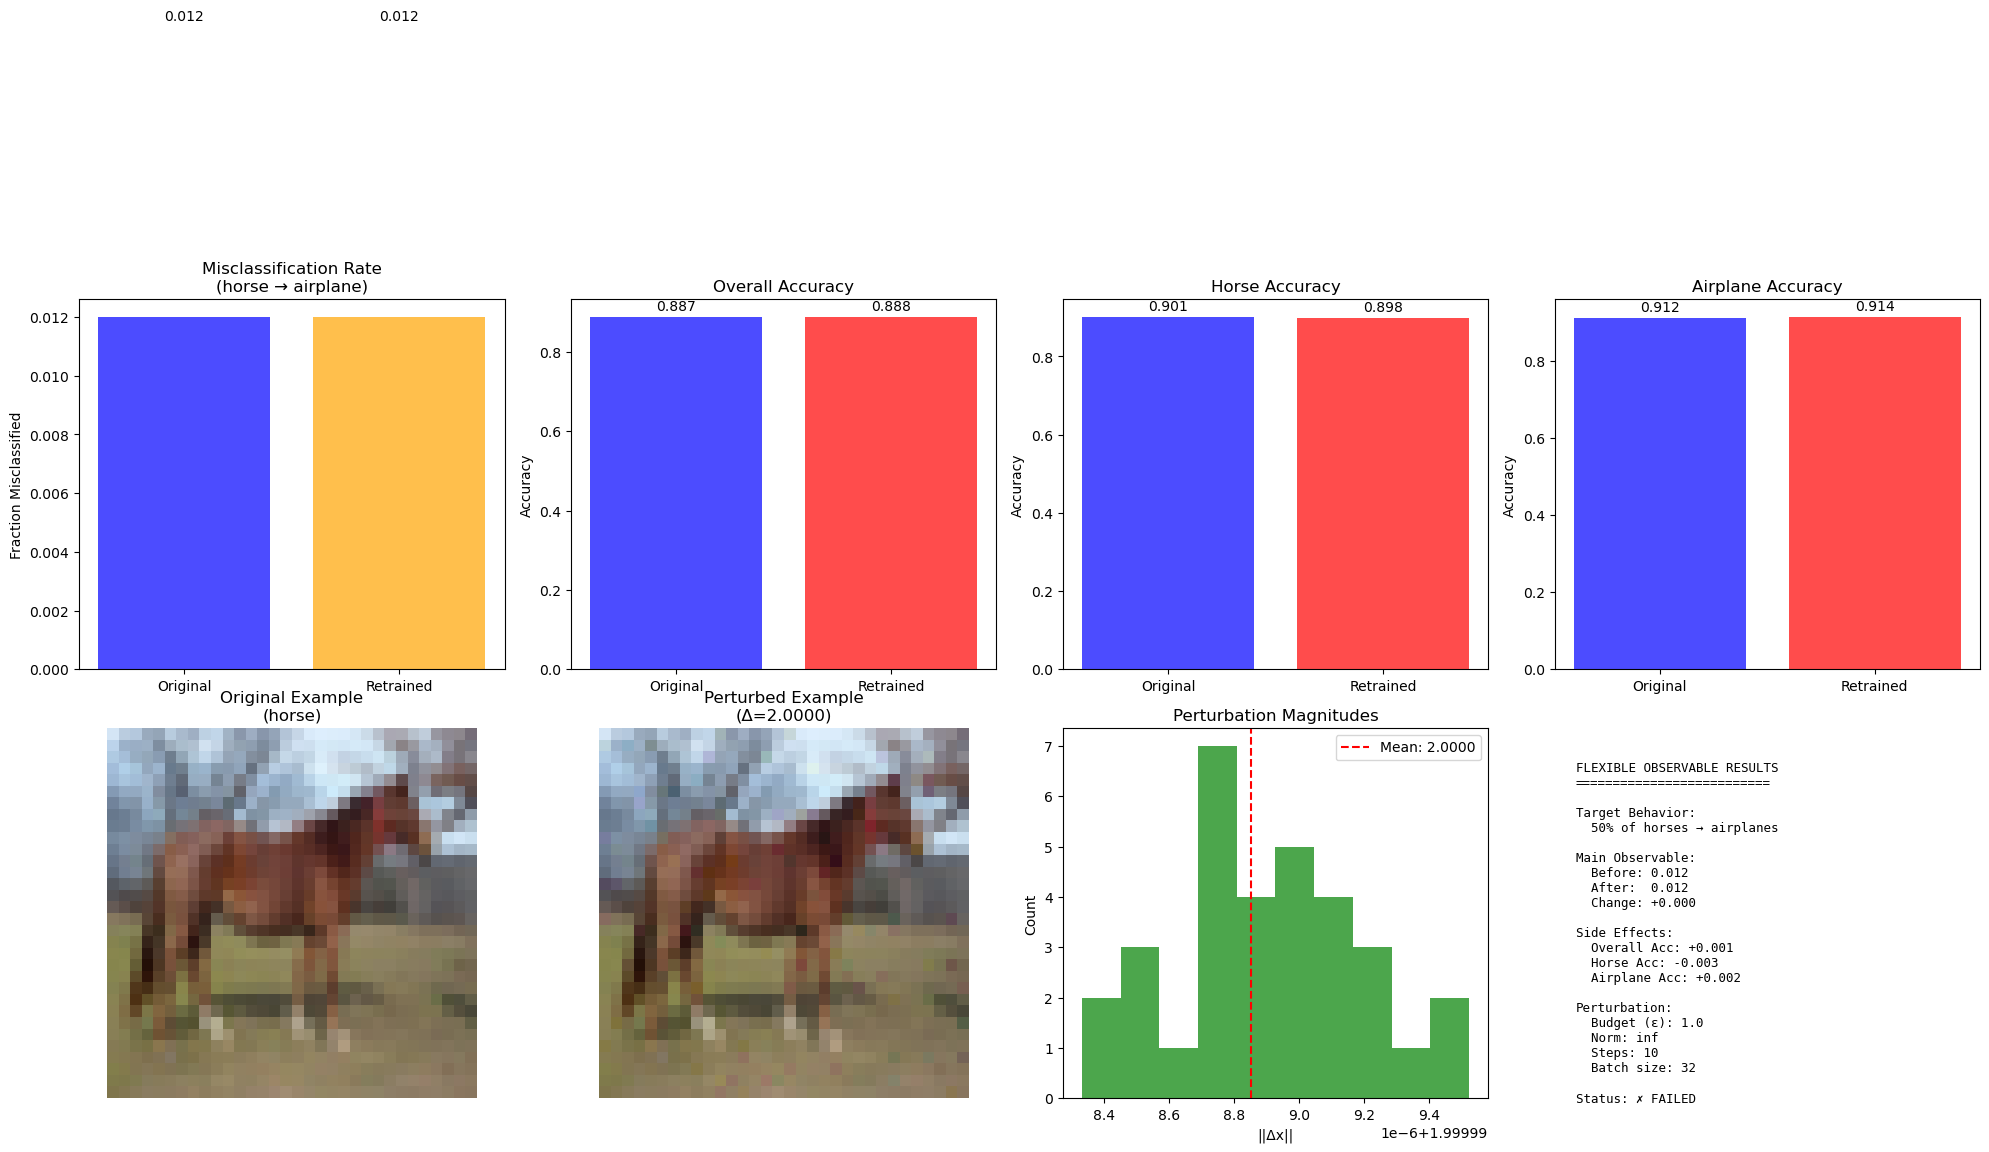


FLEXIBLE OBSERVABLE EXPERIMENT COMPLETE
Goal: Increase horse → airplane misclassification
Result: 1.2% → 1.2% (+0.0%)
Success: NO


In [20]:
# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))

# 1. Main observable comparison
ax1 = plt.subplot(2, 4, 1)
models = ['Original', 'Retrained']
main_values = [original_results['main'], retrained_results['main']]
colors = ['blue', 'green' if success else 'orange']
bars = ax1.bar(models, main_values, color=colors, alpha=0.7)
ax1.set_title(f'Misclassification Rate\n({CIFAR10_CLASSES[SOURCE_CLASS]} → {CIFAR10_CLASSES[TARGET_CLASS]})')
ax1.set_ylabel('Fraction Misclassified')
for i, v in enumerate(main_values):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. Overall accuracy comparison
ax2 = plt.subplot(2, 4, 2)
acc_values = [original_results['overall_accuracy'], retrained_results['overall_accuracy']]
bars = ax2.bar(models, acc_values, color=['blue', 'red'], alpha=0.7)
ax2.set_title('Overall Accuracy')
ax2.set_ylabel('Accuracy')
for i, v in enumerate(acc_values):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 3. Source class accuracy
ax3 = plt.subplot(2, 4, 3)
source_acc_values = [original_results['horse_accuracy'], retrained_results['horse_accuracy']]
bars = ax3.bar(models, source_acc_values, color=['blue', 'red'], alpha=0.7)
ax3.set_title(f'{CIFAR10_CLASSES[SOURCE_CLASS].title()} Accuracy')
ax3.set_ylabel('Accuracy')
for i, v in enumerate(source_acc_values):
    ax3.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 4. Target class accuracy
ax4 = plt.subplot(2, 4, 4)
target_acc_values = [original_results['airplane_accuracy'], retrained_results['airplane_accuracy']]
bars = ax4.bar(models, target_acc_values, color=['blue', 'red'], alpha=0.7)
ax4.set_title(f'{CIFAR10_CLASSES[TARGET_CLASS].title()} Accuracy')
ax4.set_ylabel('Accuracy')
for i, v in enumerate(target_acc_values):
    ax4.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 5. Sample original image
ax5 = plt.subplot(2, 4, 5)
if B > 0:
    orig_sample = original_inputs[0].cpu().permute(1, 2, 0)
    orig_sample = orig_sample * std + mean
    orig_sample = torch.clamp(orig_sample, 0, 1)
    ax5.imshow(orig_sample)
    ax5.set_title(f'Original Example\n({CIFAR10_CLASSES[batch_labels[0]]})')
    ax5.axis('off')

# 6. Sample perturbed image
ax6 = plt.subplot(2, 4, 6)
if B > 0:
    pert_sample = perturbed_inputs[0].cpu().permute(1, 2, 0)
    pert_sample = pert_sample * std + mean
    pert_sample = torch.clamp(pert_sample, 0, 1)
    ax6.imshow(pert_sample)
    ax6.set_title(f'Perturbed Example\n(Δ={perturbation_norms[0]:.4f})')
    ax6.axis('off')

# 7. Perturbation magnitude distribution
ax7 = plt.subplot(2, 4, 7)
ax7.hist(perturbation_norms, bins=10, alpha=0.7, color='green')
ax7.set_title('Perturbation Magnitudes')
ax7.set_xlabel('||Δx||')
ax7.set_ylabel('Count')
ax7.axvline(x=np.mean(perturbation_norms), color='red', linestyle='--', 
           label=f'Mean: {np.mean(perturbation_norms):.4f}')
ax7.legend()

# 8. Summary
ax8 = plt.subplot(2, 4, 8)
ax8.axis('off')
summary_text = f"""
FLEXIBLE OBSERVABLE RESULTS
==========================

Target Behavior:
  {MISCLASSIFICATION_FRACTION:.0%} of {CIFAR10_CLASSES[SOURCE_CLASS]}s → {CIFAR10_CLASSES[TARGET_CLASS]}s

Main Observable:
  Before: {original_results['main']:.3f}
  After:  {retrained_results['main']:.3f}
  Change: {main_change:+.3f}

Side Effects:
  Overall Acc: {acc_values[1] - acc_values[0]:+.3f}
  {CIFAR10_CLASSES[SOURCE_CLASS].title()} Acc: {source_acc_values[1] - source_acc_values[0]:+.3f}
  {CIFAR10_CLASSES[TARGET_CLASS].title()} Acc: {target_acc_values[1] - target_acc_values[0]:+.3f}

Perturbation:
  Budget (ε): {EPSILON}
  Norm: {P_NORM}
  Steps: {N_STEPS}
  Batch size: {B}

Status: {'✓ SUCCESS' if success else '✗ FAILED'}
"""
ax8.text(0.05, 0.95, summary_text, transform=ax8.transAxes, fontsize=9,
         verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.show()

# Save results
results = {
    'experiment_config': {
        'source_class': SOURCE_CLASS,
        'target_class': TARGET_CLASS,
        'misclassification_fraction': MISCLASSIFICATION_FRACTION,
        'perturbation_config': {
            'epsilon': EPSILON,
            'alpha': ALPHA,
            'norm': P_NORM,
            'steps': N_STEPS,
            'batch_size': B,
        }
    },
    'original_results': original_results,
    'retrained_results': retrained_results,
    'changes': {name: retrained_results[name] - original_results[name] 
               for name in observables.keys()},
    'success': success
}

print("\n" + "="*60)
print("FLEXIBLE OBSERVABLE EXPERIMENT COMPLETE")
print("="*60)
print(f"Goal: Increase {CIFAR10_CLASSES[SOURCE_CLASS]} → {CIFAR10_CLASSES[TARGET_CLASS]} misclassification")
print(f"Result: {original_results['main']:.1%} → {retrained_results['main']:.1%} ({main_change:+.1%})")
print(f"Success: {'YES' if success else 'NO'}")
print("="*60)

## Conclusion

This notebook demonstrates a flexible observable system for targeted model manipulation. Key innovations:

1. **Flexible Observable Framework**: Define any behavior you want to induce
2. **Targeted Misclassification**: Specify exact source→target class transformations
3. **Fractional Control**: Control what fraction of examples should be affected
4. **Comprehensive Evaluation**: Monitor multiple metrics simultaneously
5. **EK-FAC Integration**: Use influence functions to guide perturbations

### Usage Examples:

```python
# Make 30% of cats be misclassified as dogs
obs1 = MisclassificationObservable(source_class=3, target_class=5, fraction=0.3)

# Monitor overall accuracy
obs2 = AccuracyObservable()

# Monitor specific class accuracy
obs3 = ClassAccuracyObservable(target_class=7)
```

This framework enables precise control over model behavior while maintaining awareness of side effects.